In [1]:
import numpy as np
import getdist
from getdist import plots
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import utils

In [2]:
# pairs = [[56, 94], [57, 95], [58, 96], [59, 97]]
pairs = [[79, 98], [80, 99], [81, 100], [82, 101]]
indices = [index for pair in pairs for index in pair]
chains = {}
for i in indices:
    chains[i] = utils.load_chain(i, burn_in=0.2, smooth_2D=0.3)

../chains/MCMC98/MCMC98.1.txt
../chains/MCMC98/MCMC98.2.txt
../chains/MCMC98/MCMC98.3.txt
../chains/MCMC98/MCMC98.4.txt
Removed no burn in
../chains/MCMC99/MCMC99.1.txt
../chains/MCMC99/MCMC99.2.txt
../chains/MCMC99/MCMC99.3.txt
../chains/MCMC99/MCMC99.4.txt
Removed no burn in
../chains/MCMC100/MCMC100.1.txt
../chains/MCMC100/MCMC100.2.txt
../chains/MCMC100/MCMC100.3.txt
../chains/MCMC100/MCMC100.4.txt
Removed no burn in
../chains/MCMC101/MCMC101.1.txt
../chains/MCMC101/MCMC101.2.txt
../chains/MCMC101/MCMC101.3.txt
../chains/MCMC101/MCMC101.4.txt
Removed no burn in


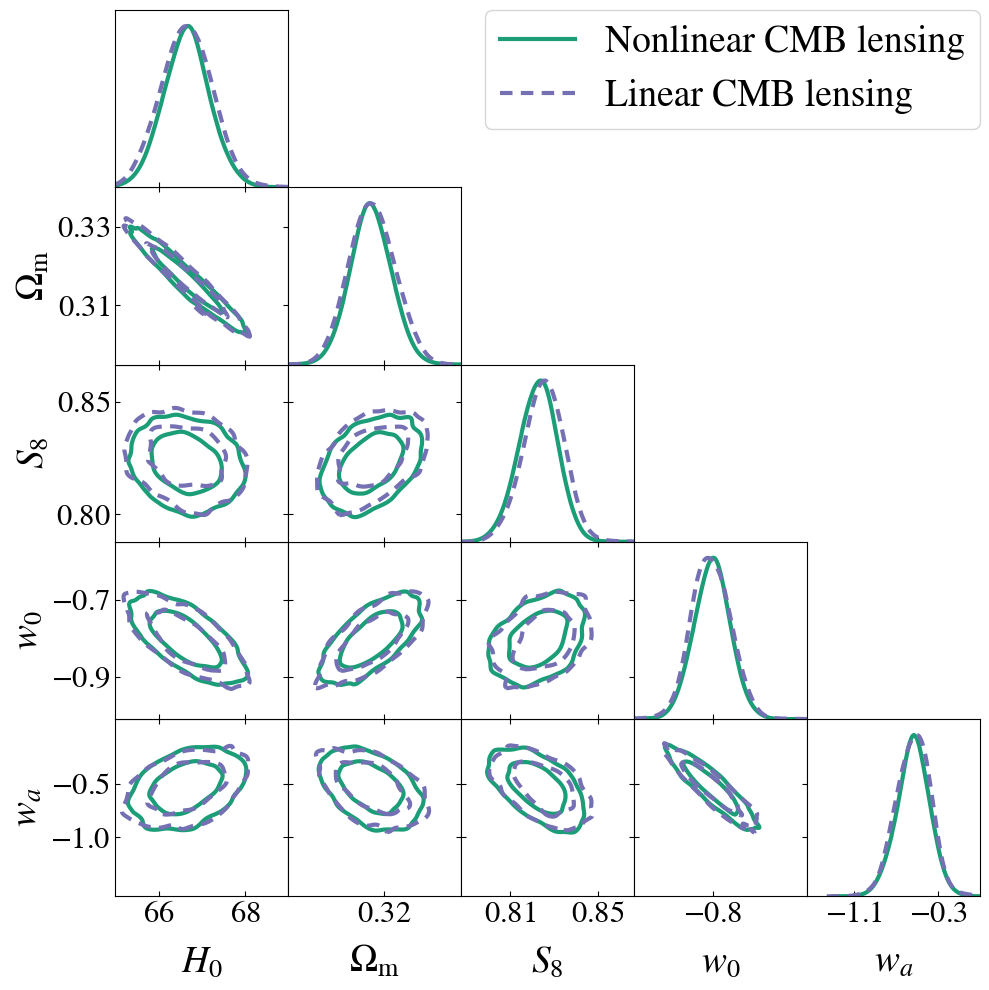

In [7]:
p = plots.get_subplot_plotter()
p.settings.axes_fontsize=25
p.settings.axes_labelsize=30
p.settings.legend_fontsize=30
p.triangle_plot(
    [chains[82], chains[101]],
    ["H0", "omegam", "S8", "w", "wa"],
    filled=[False, False, False, True],
    contour_colors=[utils.colors[0], utils.colors[2], utils.colors[3], "gray"],
    contour_lws=3,
    contour_ls=["-", "--", "-.", "-"],
    legend_labels=["Nonlinear CMB lensing", "Linear CMB lensing"],
    legend_loc="upper right",
    param_limits={"w": [-1.01, -0.55], "wa": [-1.55, 0.1], "H0": [65, 69], "omegam": [0.295, 0.34]}
)
p.fig.savefig("plots/compare_linear.pdf", bbox_inches="tight")

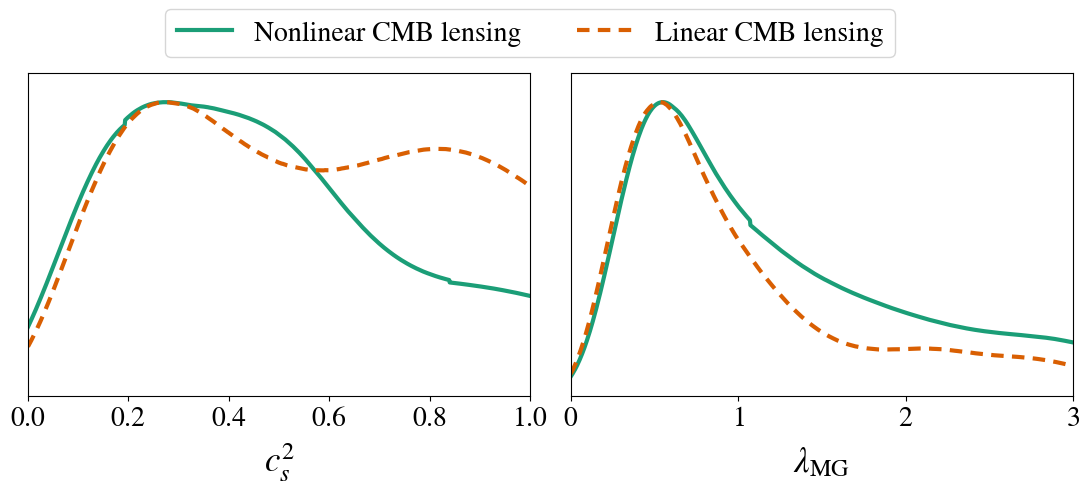

In [9]:
p = plots.get_subplot_plotter(width_inch=11, subplot_size_ratio=4/5)
p.settings.axes_fontsize=20
p.settings.axes_labelsize=25
p.settings.legend_fontsize=20
p.plots_1d(
    [chains[81], chains[100]],
    ["cs2_0", "alpha_K_0"],
    colors=utils.colors,
    lws=3,
    ls=["-", "--", "-.", "-"],
    nx=2,
    legend_labels=["Nonlinear CMB lensing", "Linear CMB lensing"],
    legend_loc="upper right",
    legend_ncol=4,
    param_limits={"w": [-1.01, -0.55], "wa": [-1.55, 0.1], "H0": [65, 69], "omegam": [0.295, 0.34]}
)
p.fig.savefig("plots/compare_linear_cs2.pdf", bbox_inches="tight")

In [10]:
aktypes = [1, 1, 2, 2, 4, 4, 3, 3]
mus_all = []

for chain_index, aktype in zip(indices, aktypes):
    log_a, alpha_B, alpha_K, mus = utils.get_mu_alphas_from_chain(chains[chain_index], aktype=aktype, num_samples=1_000)
    mus_all.append(mus)

Number of samples = 552642
Number of samples after thinning = 1002
Number of samples = 106748
Number of samples after thinning = 1008
Number of samples = 505212
Number of samples after thinning = 1001
Number of samples = 139238
Number of samples after thinning = 1002
Number of samples = 223429
Number of samples after thinning = 1002
Number of samples = 52184
Number of samples after thinning = 1004
Number of samples = 94885
Number of samples after thinning = 1010
Number of samples = 31846
Number of samples after thinning = 1028


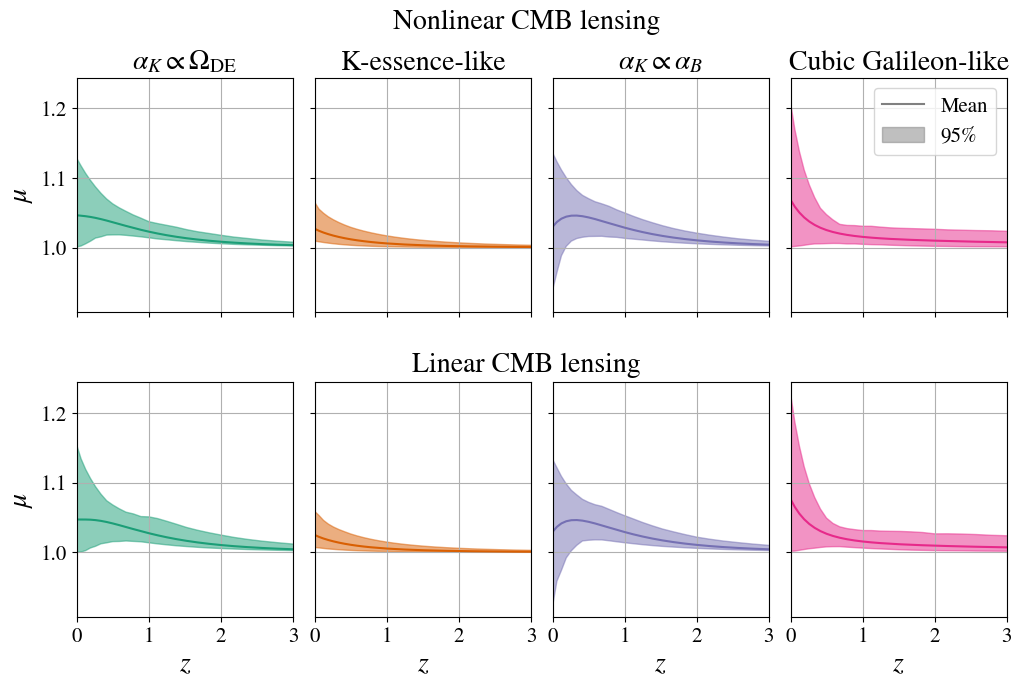

In [11]:
fig, axs = plt.subplots(2, 4, sharey=True, sharex=True, figsize=(12,7), gridspec_kw={"wspace": 0.1, "hspace": 0.3})
mean_line = Line2D([], [], ls="-", color="gray", label="Mean")
error_patch = Patch(color="gray", alpha=0.5, label="95%")
titles = ["$\\alpha_K \\propto \\Omega_\\mathrm{DE}$", "K-essence-like", "$\\alpha_K \\propto \\alpha_B$", "Cubic Galileon-like"]
for i, color in enumerate(utils.colors[:4]):
    z = 10**-log_a - 1
    
    axs[0, i].plot(z, np.mean(mus_all[2*i], axis=0), color=color)
    axs[0, i].fill_between(z, np.percentile(mus_all[2*i], 2.5, axis=0), np.percentile(mus_all[2*i], 97.5, axis=0), color=color,  alpha=0.5)
    axs[1, i].plot(z, np.mean(mus_all[2*i+1], axis=0), color=color)
    axs[1, i].fill_between(z, np.percentile(mus_all[2*i+1], 2.5, axis=0), np.percentile(mus_all[2*i+1], 97.5, axis=0), color=color,  alpha=0.5)

axs[0, 0].set_ylabel("$\\mu$", fontsize=20)
axs[1, 0].set_ylabel("$\\mu$", fontsize=20)
for ax, title in zip(axs.flatten()[:4], titles):
    ax.set_title(title, fontsize=20)
for ax in axs.flatten()[4:]:
    ax.set_xlabel("$z$", fontsize=20)
for ax in axs.flatten(): 
    ax.set_xlim(0, 3)
    ax.tick_params(axis="both", labelsize=15)
    ax.grid()

fig.legend(handles=[mean_line, error_patch], fontsize=15, bbox_to_anchor=(0.9,0.88))
fig.text(0.5, 0.46, "Linear CMB lensing", fontsize=20, ha="center")
fig.text(0.5, 0.95, "Nonlinear CMB lensing", fontsize=20, ha="center")
    
plt.savefig(f"plots/compare_linear_mu.pdf", bbox_inches="tight")